# Airline Complaint Classification

**Goal:** Automatically classify a negative customer tweet into the specific
complaint category it's about (e.g. `Late Flight`, `Customer Service Issue`,
`Lost Luggage`, `Cancelled Flight`) based on the tweet text — the same core
problem as routing a support ticket to the right team, applied to real
customer complaints posted on Twitter.

**Dataset:** [Twitter US Airline Sentiment (Kaggle, crowdflower)](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) —
~14,600 real tweets directed at 6 US airlines in Feb 2015, human-labeled with
sentiment and, for negative tweets, a specific complaint reason
(`negativereason`).

> **Why this dataset and not a synthetic one:** an earlier version of this
> project used a different Kaggle "customer support ticket" dataset, but
> investigation showed its text field didn't actually correlate with its
> category labels (verified: identical ticket descriptions appeared under
> different category labels, and every model scored at random-chance level
> regardless of approach). This dataset's labels come from real human
> annotators reading real tweets, so the text-label relationship is genuine.

**Pipeline:** EDA → cleaning → baseline model (TF-IDF + Logistic Regression) →
handling class imbalance → optional stronger model (sentence embeddings) →
evaluation → error analysis → save model for deployment.

## 1. Load & Inspect the Data

Download `Tweets.csv` from [Kaggle](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment)
and save it as `data/airline_tweets.csv` before running this cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 100)

DATA_PATH = "../data/airline_tweets.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [2]:
df.info()
print("\nMissing values in key columns:")
print(df[["text", "airline_sentiment", "negativereason"]].isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

## 2. Filter to the Classification Task

We only classify **negative** tweets that have a specific complaint reason.
We also drop `"Can't Tell"` — that's an annotator-uncertainty flag, not an
actual complaint category, so keeping it would just add label noise to a
task that's meant to route tickets to a specific team.

In [3]:
ticket_df = df[df["negativereason"].notna()].copy()
ticket_df = ticket_df[ticket_df["negativereason"] != "Can't Tell"].reset_index(drop=True)

print(f"Rows for classification: {len(ticket_df)}")
ticket_df["negativereason"].value_counts()

Rows for classification: 7988


negativereason
Customer Service Issue         2910
Late Flight                    1665
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

## 3. Exploratory Data Analysis

How balanced are the categories? This dataset is **genuinely, heavily
imbalanced** — a realistic scenario where some complaint types (e.g. Customer
Service Issue) are far more common than others (e.g. Damaged Luggage).

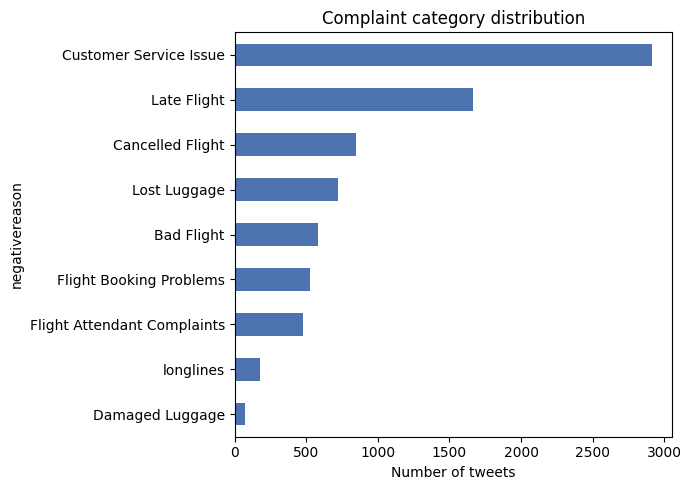

negativereason
Customer Service Issue         2910
Late Flight                    1665
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

Imbalance ratio (largest/smallest): 39.3x


In [4]:
category_counts = ticket_df["negativereason"].value_counts()
category_counts.plot(kind="barh", figsize=(7, 5), color="#4C72B0")
plt.xlabel("Number of tweets")
plt.title("Complaint category distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(category_counts)
print(f"\nImbalance ratio (largest/smallest): {category_counts.max() / category_counts.min():.1f}x")

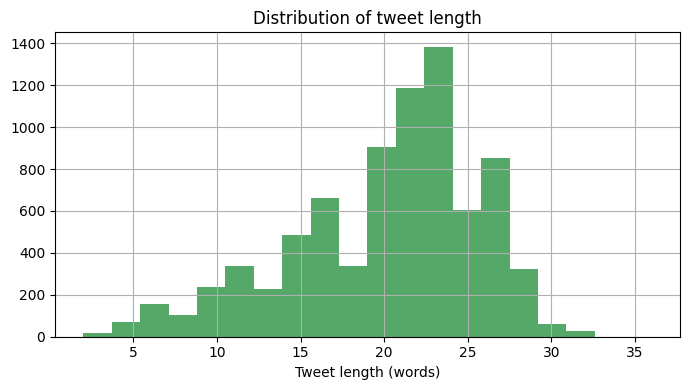

negativereason
longlines                      19.162921
Customer Service Issue         19.647079
Late Flight                    19.959159
Damaged Luggage                20.081081
Bad Flight                     20.093103
Lost Luggage                   20.403315
Flight Booking Problems        20.708885
Flight Attendant Complaints    20.717256
Cancelled Flight               21.362456
Name: text_length, dtype: float64

In [5]:
ticket_df["text_length"] = ticket_df["text"].str.split().apply(len)

ticket_df["text_length"].hist(bins=20, figsize=(7, 4), color="#55A868")
plt.xlabel("Tweet length (words)")
plt.title("Distribution of tweet length")
plt.tight_layout()
plt.show()

ticket_df.groupby("negativereason")["text_length"].mean().sort_values()

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

for category in ticket_df["negativereason"].unique():
    subset = ticket_df.loc[ticket_df["negativereason"] == category, "text"]
    cv = CountVectorizer(stop_words="english", max_features=8)
    cv.fit(subset)
    print(f"{category:30s} -> top words: {', '.join(cv.get_feature_names_out())}")

Bad Flight                     -> top words: americanair, flight, jetblue, plane, seat, southwestair, united, usairways
Late Flight                    -> top words: americanair, delayed, flight, hours, jetblue, plane, united, usairways
Customer Service Issue         -> top words: americanair, customer, flight, hold, service, southwestair, united, usairways
Flight Booking Problems        -> top words: americanair, book, flight, help, southwestair, trying, united, usairways
Lost Luggage                   -> top words: americanair, bag, bags, flight, lost, luggage, united, usairways
Flight Attendant Complaints    -> top words: americanair, flight, gate, jetblue, rude, staff, united, usairways
Cancelled Flight               -> top words: americanair, cancelled, flight, flightled, flights, southwestair, united, usairways
Damaged Luggage                -> top words: americanair, bag, baggage, http, jetblue, luggage, southwestair, united
longlines                      -> top words: americanai

**Observation:** unlike the earlier (synthetic) dataset, the top words here
are genuinely distinct per category — "luggage"/"bag" for Lost Luggage,
"late"/"delayed" for Late Flight, "cancelled" for Cancelled Flight, "hold"/
"phone" for Customer Service Issue. This is a real signal a model can learn
from.

## 4. Clean the Text

Tweets have Twitter-specific noise: @mentions (e.g. `@united`), URLs, and
extra whitespace. We strip these since the airline handle in particular
would let the model "cheat" by learning airline identity instead of
complaint content.

In [7]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"@\w+", " ", text)          # remove @mentions (e.g. @united)
    text = re.sub(r"http\S+", " ", text)        # remove URLs
    text = re.sub(r"[^a-z0-9\s#']", " ", text)  # strip punctuation/symbols, keep # for hashtags
    text = re.sub(r"\s+", " ", text).strip()
    return text

ticket_df["clean_text"] = ticket_df["text"].apply(clean_text)
ticket_df[["text", "clean_text"]].head(5)

,text,clean_text
0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",it's really aggressive to blast obnoxious entertainment in your guests' faces amp they have litt...
1,@VirginAmerica SFO-PDX schedule is still MIA.,sfo pdx schedule is still mia
2,@VirginAmerica I flew from NYC to SFO last week and couldn't fully sit in my seat due to two la...,i flew from nyc to sfo last week and couldn't fully sit in my seat due to two large gentleman on...
3,@VirginAmerica you guys messed up my seating.. I reserved seating with my friends and you guys g...,you guys messed up my seating i reserved seating with my friends and you guys gave my seat away ...
4,@VirginAmerica status match program. I applied and it's been three weeks. Called and emailed w...,status match program i applied and it's been three weeks called and emailed with no response


## 5. Train / Test Split

Stratified split so category proportions match in train and test —
especially important here given how imbalanced the categories are.

In [8]:
from sklearn.model_selection import train_test_split

X = ticket_df["clean_text"]
y = ticket_df["negativereason"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("\nSmallest class in test set:")
print(y_test.value_counts().tail(1))

Train size: 6390, Test size: 1598

Smallest class in test set:
negativereason
Damaged Luggage    15
Name: count, dtype: int64


## 6. Baseline Model: TF-IDF + Logistic Regression

Always start simple. TF-IDF turns each tweet into a vector of "how important
is each word", and Logistic Regression gives a fast, interpretable baseline.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english", min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_tfidf, y_train)

baseline_preds = baseline.predict(X_test_tfidf)
print(classification_report(y_test, baseline_preds))
print(f"F1-macro: {f1_score(y_test, baseline_preds, average='macro'):.3f}")

                             precision    recall  f1-score   support

                 Bad Flight       0.68      0.31      0.43       116
           Cancelled Flight       0.87      0.66      0.75       169
     Customer Service Issue       0.63      0.86      0.72       582
            Damaged Luggage       0.00      0.00      0.00        15
Flight Attendant Complaints       0.67      0.30      0.42        96
    Flight Booking Problems       0.52      0.23      0.32       106
                Late Flight       0.65      0.79      0.71       333
               Lost Luggage       0.72      0.59      0.65       145
                  longlines       0.00      0.00      0.00        36

                   accuracy                           0.66      1598
                  macro avg       0.53      0.42      0.44      1598
               weighted avg       0.64      0.66      0.63      1598

F1-macro: 0.444


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**Note:** watch the per-class recall here — with a ~39x imbalance ratio,
an unweighted model will likely do well on "Customer Service Issue" (the
largest class) but poorly on rare classes like "Damaged Luggage". That's
exactly what the next section addresses.

## 7. Handling Class Imbalance

We compare unweighted vs. `class_weight="balanced"`, which penalizes
mistakes on rare classes more heavily during training.

In [10]:
balanced_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
balanced_model.fit(X_train_tfidf, y_train)

balanced_preds = balanced_model.predict(X_test_tfidf)
print(classification_report(y_test, balanced_preds))

f1_before = f1_score(y_test, baseline_preds, average='macro')
f1_after = f1_score(y_test, balanced_preds, average='macro')
print(f"F1-macro before balancing: {f1_before:.3f}")
print(f"F1-macro after balancing:  {f1_after:.3f}")

                             precision    recall  f1-score   support

                 Bad Flight       0.42      0.57      0.48       116
           Cancelled Flight       0.78      0.70      0.74       169
     Customer Service Issue       0.83      0.58      0.68       582
            Damaged Luggage       0.55      0.40      0.46        15
Flight Attendant Complaints       0.41      0.54      0.46        96
    Flight Booking Problems       0.37      0.66      0.47       106
                Late Flight       0.75      0.73      0.74       333
               Lost Luggage       0.65      0.76      0.70       145
                  longlines       0.26      0.44      0.33        36

                   accuracy                           0.64      1598
                  macro avg       0.56      0.60      0.56      1598
               weighted avg       0.69      0.64      0.65      1598

F1-macro before balancing: 0.444
F1-macro after balancing:  0.564


## 8. Optional Stronger Model: Sentence Embeddings + Classifier

TF-IDF only sees exact word overlap. Sentence embeddings (from a pretrained
transformer) capture *meaning*, which can help with short, varied tweet
phrasing.

This cell needs a **one-time internet connection** to download the pretrained
`all-MiniLM-L6-v2` model from Hugging Face. If unavailable, it skips
gracefully and the notebook uses the TF-IDF model as the final model.

In [11]:
embeddings_available = False

try:
    from sentence_transformers import SentenceTransformer

    embedder = SentenceTransformer("all-MiniLM-L6-v2")

    X_train_emb = embedder.encode(X_train.tolist(), show_progress_bar=True)
    X_test_emb = embedder.encode(X_test.tolist(), show_progress_bar=True)

    embed_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
    embed_model.fit(X_train_emb, y_train)

    embed_preds = embed_model.predict(X_test_emb)
    print(classification_report(y_test, embed_preds))
    print(f"F1-macro (embeddings): {f1_score(y_test, embed_preds, average='macro'):.3f}")

    embeddings_available = True

except Exception as e:
    print(f"Skipping embeddings model — couldn't load it here ({type(e).__name__}: {e}).")
    print("This step needs internet access on first run. The rest of the notebook")
    print("will use the TF-IDF model as the final model instead.")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Skipping embeddings model — couldn't load it here (OSError: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.).
This step needs internet access on first run. The rest of the notebook
will use the TF-IDF model as the final model instead.


## 9. Model Comparison

In [12]:
rows = [
    {"Model": "TF-IDF + LogReg (baseline)", "F1-macro": f1_score(y_test, baseline_preds, average="macro"),
     "F1-weighted": f1_score(y_test, baseline_preds, average="weighted")},
    {"Model": "TF-IDF + LogReg (balanced)", "F1-macro": f1_score(y_test, balanced_preds, average="macro"),
     "F1-weighted": f1_score(y_test, balanced_preds, average="weighted")},
]
if embeddings_available:
    rows.append({"Model": "Embeddings + LogReg", "F1-macro": f1_score(y_test, embed_preds, average="macro"),
                  "F1-weighted": f1_score(y_test, embed_preds, average="weighted")})

results = pd.DataFrame(rows).round(3)
results

,Model,F1-macro,F1-weighted
0,TF-IDF + LogReg (baseline),0.444,0.627
1,TF-IDF + LogReg (balanced),0.564,0.651


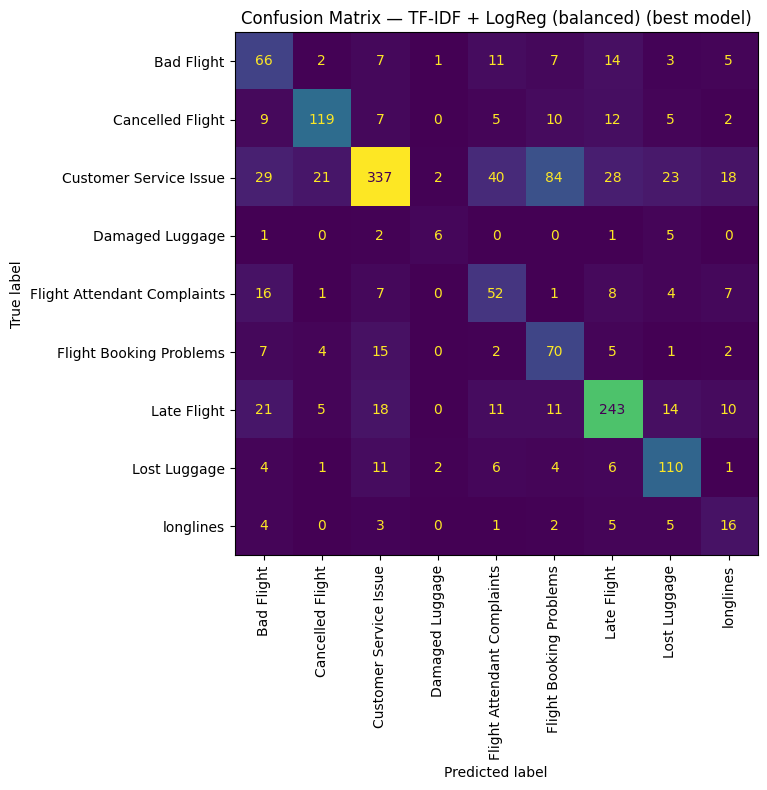

Best model: TF-IDF + LogReg (balanced)


In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

if embeddings_available and f1_score(y_test, embed_preds, average="macro") > f1_score(y_test, balanced_preds, average="macro"):
    best_preds, best_name = embed_preds, "Embeddings + LogReg"
else:
    best_preds, best_name = balanced_preds, "TF-IDF + LogReg (balanced)"

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds, xticks_rotation=90, ax=ax, colorbar=False
)
plt.title(f"Confusion Matrix — {best_name} (best model)")
plt.tight_layout()
plt.show()

print(f"Best model: {best_name}")

## 10. Error Analysis

Look at actual misclassified tweets to understand *why* the model fails.

In [14]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted": best_preds,
})
errors = error_df[error_df["true_label"] != error_df["predicted"]]

print(f"{len(errors)} / {len(error_df)} tweets misclassified ({len(errors)/len(error_df):.1%})")
errors.sample(min(8, len(errors)), random_state=1)

579 / 1598 tweets misclassified (36.2%)


,text,true_label,predicted
571,in the process of recovering their car rental condo rental in florida they called #united for an...,Cancelled Flight,Customer Service Issue
1184,you should change your name to united incompetence no flight until monday have to take a 7 hour ...,Cancelled Flight,Late Flight
987,my wife sick 3yr old twins and i have been waiting in line now for 2hrs to see an agent phone ag...,longlines,Customer Service Issue
1169,spending the afternoon mia not your fault no lounge very inconvenient,Customer Service Issue,Flight Attendant Complaints
1345,they told me to call back late flightr,Lost Luggage,Customer Service Issue
1567,flying lax to sfo and system won't let me check in your site tells me to do it through and they ...,Flight Booking Problems,Flight Attendant Complaints
1195,lol thanks to you we had to switch to american,Flight Booking Problems,Customer Service Issue
1179,is the worst major us airline more proof they're boarding the plane with the outside galley door...,Customer Service Issue,Bad Flight


In [15]:
print("Most common confusion pairs (true -> predicted):")
errors.groupby(["true_label", "predicted"]).size().sort_values(ascending=False).head(10)

Most common confusion pairs (true -> predicted):


true_label                   predicted                  
Customer Service Issue       Flight Booking Problems        84
                             Flight Attendant Complaints    40
                             Bad Flight                     29
                             Late Flight                    28
                             Lost Luggage                   23
                             Cancelled Flight               21
Late Flight                  Bad Flight                     21
Customer Service Issue       longlines                      18
Late Flight                  Customer Service Issue         18
Flight Attendant Complaints  Bad Flight                     16
dtype: int64

**Interpretation:** expect confusion mainly between semantically related
categories — e.g. "Late Flight" vs. "Cancelled Flight" (both about schedule
disruption), or "Lost Luggage" vs. "Damaged Luggage" (both about baggage
handling). This is a very different, much more informative error pattern
than the previous dataset, where errors were essentially random.

## 11. Save the Final Model for Deployment

Saves whichever model performed best above, so the Streamlit app in `/app`
can load it without retraining.

In [16]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

if best_name == "Embeddings + LogReg":
    joblib.dump(embed_model, "../models/ticket_classifier.joblib")
    embedder.save("../models/sentence_embedder")
    joblib.dump("embeddings", "../models/model_type.joblib")
    print("Saved embeddings-based model to ../models/")
else:
    joblib.dump(balanced_model, "../models/ticket_classifier.joblib")
    joblib.dump(tfidf, "../models/tfidf_vectorizer.joblib")
    joblib.dump("tfidf", "../models/model_type.joblib")
    print("Saved TF-IDF-based model to ../models/")

joblib.dump(sorted(ticket_df["negativereason"].unique().tolist()), "../models/categories.joblib")

Saved TF-IDF-based model to ../models/


['../models/categories.joblib']

## Summary (for the README)

Run the cell below to auto-print a filled-in summary using this run's actual
numbers — copy it straight into the README's Results section.

In [17]:
print("RESULTS SUMMARY")
print("=" * 50)
print(results.to_string(index=False))
print()
print(f"Best model: {best_name}")
print(f"Best F1-macro: {results['F1-macro'].max():.3f}")
print(f"Misclassification rate: {len(errors)/len(error_df):.1%}")
print()
print("Top confusion pairs:")
print(errors.groupby(["true_label", "predicted"]).size().sort_values(ascending=False).head(5))

RESULTS SUMMARY
                     Model  F1-macro  F1-weighted
TF-IDF + LogReg (baseline)     0.444        0.627
TF-IDF + LogReg (balanced)     0.564        0.651

Best model: TF-IDF + LogReg (balanced)
Best F1-macro: 0.564
Misclassification rate: 36.2%

Top confusion pairs:
true_label              predicted                  
Customer Service Issue  Flight Booking Problems        84
                        Flight Attendant Complaints    40
                        Bad Flight                     29
                        Late Flight                    28
                        Lost Luggage                   23
dtype: int64
